# Hola!
![Gatito fogata](https://media.tenor.com/8exEmy9vbZ0AAAAM/cat-kitty.gif)

# **1. INTRODUCCION**

## ¿Qué es el Analisis Exploratorio de Datos (EDA)?
Es la etapa inicial dentro de un proyecto de datos, el objetivo de esta etapa es **ENTENDER EL DATASET** antes de construir cualquier modelo o sistema. En esta fase se analizan las variables, distribuciones, relaciones y posibles problemas con los datos, como por ejemplo:
- valores nulos
- outliers
- inconsistencias.

Mas que buscar respuestas definitivas, el EDA nos permite **hacernos las preguntas correctas sobre los datos y descubrir patrones** que no son evidentes a simple vista.

## ¿Cual es el proposito del EDA?

El proposito principal es **conocer el comportamiento de los datos**. A traves de graficos, estadisticas y analisis simples, se puede identificar que variables son relevantes, como se comportan y si existe alguna relacion con el objetivo del proyecto.


## ¿Como se diferencia del proceso de transformacion de datos?
El proceso de transformacion de datos es una etapa distinta que **ocurre despues del EDA**. Mientras que el EDA se enfoca en explorar y entender, la transformacion se enfoca en **preparar los datos para ser utilizados en produccion o en modelos**.

# **2. EDA Citibike Trips**

### ¿Puedo estimar si un viaje será largo según el usuario, la estación, la hora y la fecha de inicio?
**Objetivo del analisis:** evaluar si la muestra extraida desde BigQuery contiene informacion suficiente para construir un modelo batch que pueda categorizar un viaje como **CORTO** o **LARGO**, usando solo datos disponibles al inicio del viaje.

Se buscan responder preguntas como:
1. ¿Que columnas tengo disponibles?
2. ¿Cual sera mi variable objetivo?
3. ¿Que variable puedo usar antes de que el viaje termine?
4. ¿Hay patrones visibles entre la duracion y variables como hora, estacion, tipo de usuario, genero o edad?
5. ¿El dataset parece util para crear un primer modelo de clasificacion?

### Vamos paso a paso!

## 1. Importar librerias

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Cargar la muestra Parquet

In [ ]:
import gdown
dataset = '1KJOrcSQRhuCQA4PGXCi1d8m7HnnUt54_'
url = f'https://drive.google.com/uc?id={dataset}'

gdown.download(url, 'citibike_trips.parquet', quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1KJOrcSQRhuCQA4PGXCi1d8m7HnnUt54_
To: /content/citibike_trips.parquet
100%|██████████| 6.11M/6.11M [00:00<00:00, 28.3MB/s]


'citibike_trips.parquet'

In [ ]:
df = pd.read_parquet('/content/citibike_trips.parquet')
df.head(5)

,tripduration,starttime,start_station_id,end_station_id,usertype,gender,birth_year
0,213,2017-05-04 16:53:04,151,3435,Subscriber,male,1949
1,759,2013-11-21 06:57:23,521,475,Subscriber,male,1951
2,452,2016-09-09 07:37:13,3155,3141,Subscriber,male,1947
3,842,2016-09-27 07:32:35,3156,517,Subscriber,male,1949
4,1018,2015-04-11 20:06:10,302,375,Subscriber,male,1951


## 3. Primera revision general
Buscamos entender que "forma" tiene la muestra:
- Tamaño
- Tipos de datos
- Valores nulos

In [ ]:
display(df.head(3))
print('')
print(f'Filas y columas: {df.shape}\n')
df.info()

,tripduration,starttime,start_station_id,end_station_id,usertype,gender,birth_year
0,213,2017-05-04 16:53:04,151,3435,Subscriber,male,1949
1,759,2013-11-21 06:57:23,521,475,Subscriber,male,1951
2,452,2016-09-09 07:37:13,3155,3141,Subscriber,male,1947



Filas y columas: (474491, 7)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 474491 entries, 0 to 474490
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   tripduration      474491 non-null  Int64         
 1   starttime         474491 non-null  datetime64[us]
 2   start_station_id  474491 non-null  Int64         
 3   end_station_id    474491 non-null  Int64         
 4   usertype          474491 non-null  object        
 5   gender            474491 non-null  object        
 6   birth_year        474491 non-null  Int64         
dtypes: Int64(4), datetime64[us](1), object(2)
memory usage: 27.2+ MB


In [ ]:
nulos = df.isna().sum().to_frame('nulos')
nulos['porcentaje'] = (nulos['nulos'] / len(df) * 100).round(2)
nulos

,nulos,porcentaje
tripduration,0,0.0
starttime,0,0.0
start_station_id,0,0.0
end_station_id,0,0.0
usertype,0,0.0
gender,0,0.0
birth_year,0,0.0


In [ ]:
print(f'Filas duplicadas: {df.duplicated().sum()}')

Filas duplicadas: 0


## 4. Entender cada columna

Segun la muestra, las columnas son:
- `tripduration`: duracion del viaje en segundos.
- `starttime`: fecha y hora de inicio del viaje.
- `start_station_id`: estacion de inicio.
- `end_station_id`: estacion de termino.
- `usertype`: tipo de usuario.
- `gender`: genero registrado.
- `birth_year`: año de nacimiento.

## 5. Evitar fuga de informacion o *data leakage*

Para esta pregunta:
> **¿Qué probabilidad tiene un viaje de ser largo usando solo información disponible al inicio del viaje?**

Es importante evitar el uso de variables que contengan informacion del futuro o que esten relacionadas con la duracion real del viaje, ya que si pasa esto generaria *data leakage* y haria que el modelo aprenda la respuesta en lugar de predecirla.

Para este contexto se deberian usar variables que esten disponibles al momento que el viaje comienza.

| Variable | ¿Usarla como feature? | Motivo |
|---|---:|---|
| `tripduration` | No | Es la respuesta que queremos predecir. |
| `end_station_id` | No | El destino no se conoce al iniciar el viaje. |
| `starttime` | Parcialmente | Se usa para extraer hora, dia y mes. |
| `start_station_id` | Si | Se conoce al inicio y puede influir en el tipo de viaje. |
| `usertype` | Si | Se conoce al inicio y esta fuertemente relacionado con la duracion. |
| `gender` | Si | Se conoce al inicio y aporta "señal" adicional. |
| `birth_year` | Transformada | Se transforma en edad (`age`) para mejorar su uso en el modelo. |


## 6. Analisis de la duracion del viaje

Revisaremos la distribucion de `tripduration`, porque desde esa variable construiremos la variable objetivo: viaje corto o largo.

In [ ]:
df['tripduration'].describe(percentiles=[.01, .05, .25, .50, .75, .90, .95, .99])

,tripduration
count,474491.0
mean,748.938854
std,570.16368
min,61.0
1%,111.0
5%,185.0
25%,366.0
50%,585.0
75%,960.0
90%,1485.0


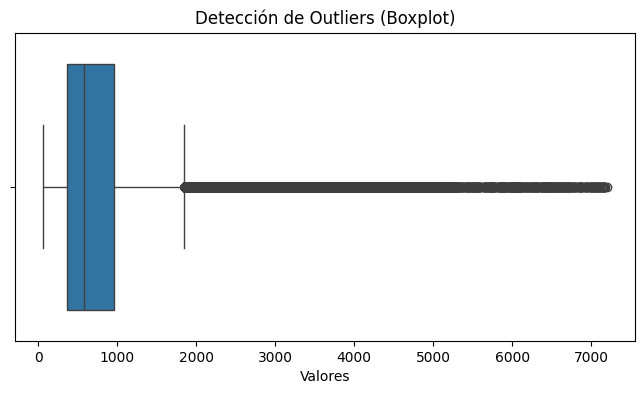

In [ ]:
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.boxplot(x=df['tripduration'])
plt.title('Detección de Outliers (Boxplot)')
plt.xlabel('Valores')
plt.show()

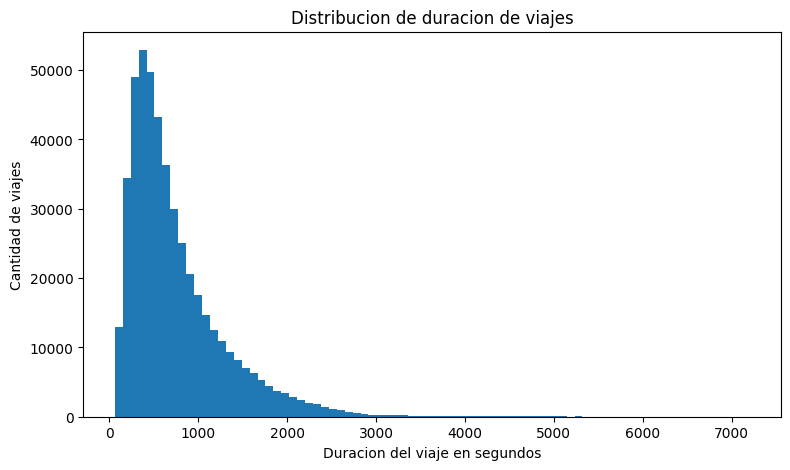

In [ ]:
plt.figure(figsize=(9,5))
plt.hist(df['tripduration'], bins=80)
plt.title('Distribucion de duracion de viajes')
plt.xlabel('Duracion del viaje en segundos')
plt.ylabel('Cantidad de viajes')
plt.show()

In [ ]:
# El siguiente grafico es el mismo que el de arriba, solo queria probar una libreria mas interactiva.

In [ ]:
import plotly.express as px

datos = df['tripduration']
fig = px.histogram(datos, nbins=80, title="Distribucion de duracion de viajes")
fig.show()

La duracion suele tener una distribucion sesgada, muchos viajes cortos y pocos viajes largos.

Por eso conviene revisar percentiles y no solo el promedio.

In [ ]:
percentiles = df['tripduration'].quantile([.25, .50, .75, .90, .95, .99])
percentiles.to_frame('tripduration segundos')

,tripduration segundos
0.25,366.0
0.50,585.0
0.75,960.0
0.90,1485.0
0.95,1853.0
0.99,2626.1


Se detectaron valores extremos en la variable `tripduration`. Estos pueden ser por errores operacionales (bicicletas no ancladas correctamente) mas que viajes reales. Se va a evaluar su impacto en los resultados del modelo (con y sin outliers) antes de borrarlos.

## 7. Definir que significa "Viaje largo"

Hay varias formas validas de definirlo. Para un primer modelo es mejor una regla clara y defendible.

Opciones comunes:
1. **Mayor a la mediana:** deja las clases balanceadas.
2. **Mayor a 15 minutos:** definicion mas interpretable.
3. **Mayor al percentil 75:** considera largos solo al 25% superior.

Para este EDA:
> Viaje largo = duracion mayor a 15 minutos (900 segundos)



In [ ]:
UMBRAL_LARGO = 15 * 60

df['viaje_largo'] = (df['tripduration'] > UMBRAL_LARGO).astype(int)
df['viaje_largo'].value_counts(normalize=True).rename({0:'corto', 1:'largo'}).to_frame('proporcion').round(5)

,proporcion
viaje_largo,
corto,0.72198
largo,0.27802


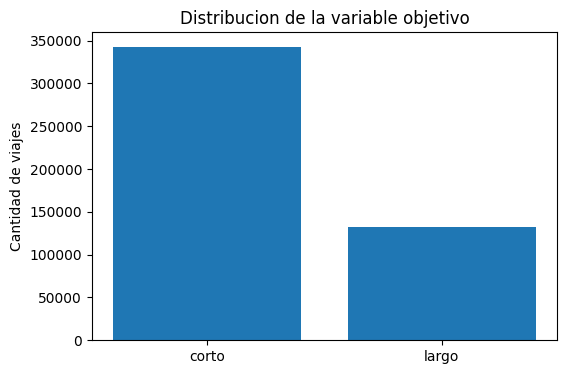

In [ ]:
conteo_target = df['viaje_largo'].value_counts().sort_index()
conteo_target.index = ['corto', 'largo']

plt.figure(figsize=(6,4))
plt.bar(conteo_target.index, conteo_target.values)
plt.title('Distribucion de la variable objetivo')
plt.ylabel('Cantidad de viajes')
plt.show()

Si una clase queda demasiado pequeña el modelo puede aprender peor sobre esa clase.

Con 15 minutos normalmente queda una clase "largo" menor, pero todavia util para clasificacion.

## 8. Crear variables disponibles al inicio del viaje

Desde `starttime` podemos crear variables temporales:
- año
- mes
- dia de la semana
- hora
- si es fin de semana

Desde `starttime` podemos sacar la edad aproximada al momento del viaje.

In [ ]:
df['year'] = df['starttime'].dt.year
df['month'] = df['starttime'].dt.month
df['hour'] = df['starttime'].dt.hour
df['dayofweek'] = df['starttime'].dt.dayofweek # lunes=0, domingo=6
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

df['age'] = df['year'] - df['birth_year']

df[['starttime', 'year', 'month', 'hour', 'dayofweek', 'is_weekend', 'birth_year', 'age']].head()

,starttime,year,month,hour,dayofweek,is_weekend,birth_year,age
0,2017-05-04 16:53:04,2017,5,16,3,0,1949,68
1,2013-11-21 06:57:23,2013,11,6,3,0,1951,62
2,2016-09-09 07:37:13,2016,9,7,4,0,1947,69
3,2016-09-27 07:32:35,2016,9,7,1,0,1949,67
4,2015-04-11 20:06:10,2015,4,20,5,1,1951,64


## 9. Revisar rangos raros o posibles outliers

Aqui buscamos valores extraños, por ejemplo edades demasiado altas

In [ ]:
df[['tripduration', 'birth_year', 'age']].describe(percentiles=[.01, .05, .25, .50, .75, .95, .99])

,tripduration,birth_year,age
count,474491.0,474491.0,474491.0
mean,748.938854,1977.472475,38.263714
std,570.16368,11.662401,11.610622
min,61.0,1885.0,16.0
1%,111.0,1948.0,20.0
5%,185.0,1956.0,24.0
25%,366.0,1969.0,29.0
50%,585.0,1980.0,36.0
75%,960.0,1987.0,46.0
95%,1853.0,1993.0,60.0


In [ ]:
print(f'Edad menor a 10: {(df['age'] < 10).sum()}')
print(f'Edad mayor a 90: {(df['age'] > 90).sum()}')

Edad menor a 10: 0
Edad mayor a 90: 246


No necesariamente se eliminan de inmediato, pero es importante identificar los outliers.

Para un modelo posterior se podrian filtrar edades poco realistas o agruparlas.

## 10. Relacion entre variables y viaje largo
Revisamos si algunas variables tienen relacion con la probabilidad de que un viaje sea largo.

In [ ]:
tabla_usertype = df.groupby('usertype')['viaje_largo'].agg(['count', 'mean']).sort_values('mean', ascending=False)
tabla_usertype = tabla_usertype.rename(columns={'count': 'cantidad viajes', 'mean': 'promedio viajes largos'})
tabla_usertype['promedio viajes largos'] = (tabla_usertype['promedio viajes largos']).round(2)
tabla_usertype.style.format({
    'promedio viajes largos': '{:.2%}'
})

,cantidad viajes,promedio viajes largos
usertype,,
Customer,8297,70.00%
Subscriber,466194,27.00%


In [ ]:
tabla_gender = df.groupby('gender')['viaje_largo'].agg(['count', 'mean']).sort_values('mean', ascending=False)
tabla_gender = tabla_gender.rename(columns={'count': 'cantidad viajes', 'mean': 'promedio viajes largos'})
tabla_gender['promedio viajes largos'] = (tabla_gender['promedio viajes largos']).round(2)
tabla_gender.style.format({
    'promedio viajes largos': '{:.2%}'
})

,cantidad viajes,promedio viajes largos
gender,,
unknown,5464,57.00%
female,114065,34.00%
male,354962,25.00%


In [ ]:
# (es la logica del calculo de arriba pero manual)
conteo_viajes_largos_female = ((df['viaje_largo'] == 1) & (df['gender'] == 'female')).sum()
conteo_viajes_mujeres = (df['gender'] == 'female').sum()
sol = conteo_viajes_largos_female / conteo_viajes_mujeres
print('CALCULO MANUAL PARA REFERENCIA')
print(f'- Total viajes de mujeres: {conteo_viajes_mujeres}')
print(f'- Total viajes largos de mujeres: {conteo_viajes_largos_female}')
print(f'- Promedio de viajes largos de mujeres (en base al total de viajes de mujeres): {sol.round(2)}')

CALCULO MANUAL PARA REFERENCIA
- Total viajes de mujeres: 114065
- Total viajes largos de mujeres: 38333
- Promedio de viajes largos de mujeres (en base al total de viajes de mujeres): 0.34


In [ ]:
tabla_weekend = df.groupby('is_weekend')['viaje_largo'].agg(['count', 'mean'])
tabla_weekend.index = ['dia laboral', 'fin de semana']
tabla_weekend = tabla_weekend.rename(columns={'count': 'cantidad viajes', 'mean': 'promedio viajes largos'})
tabla_weekend['promedio viajes largos'] = (tabla_weekend['promedio viajes largos']).round(2)
tabla_weekend.style.format({
    'promedio viajes largos': '{:.2%}'
})

,cantidad viajes,promedio viajes largos
dia laboral,371912,27.00%
fin de semana,102579,31.00%


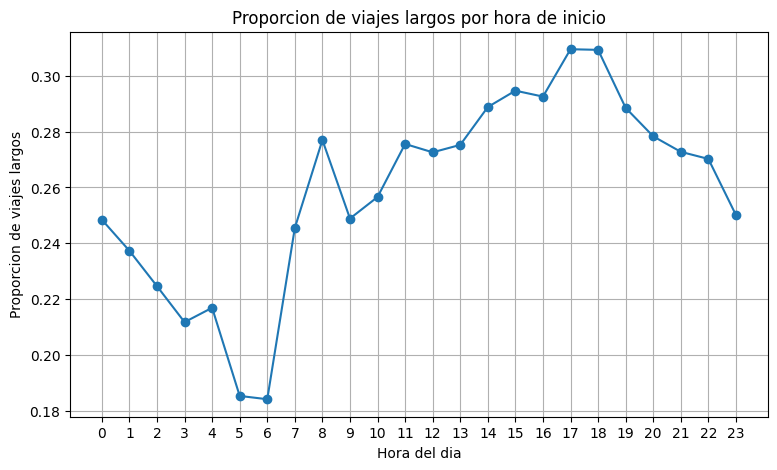

In [ ]:
hourly = df.groupby('hour')['viaje_largo'].mean()

plt.figure(figsize=(9,5))
plt.plot(hourly.index, hourly.values, marker='o')
plt.title('Proporcion de viajes largos por hora de inicio')
plt.xlabel('Hora del dia')
plt.ylabel('Proporcion de viajes largos')
plt.xticks(range(0,24))
plt.grid(True)
plt.show()

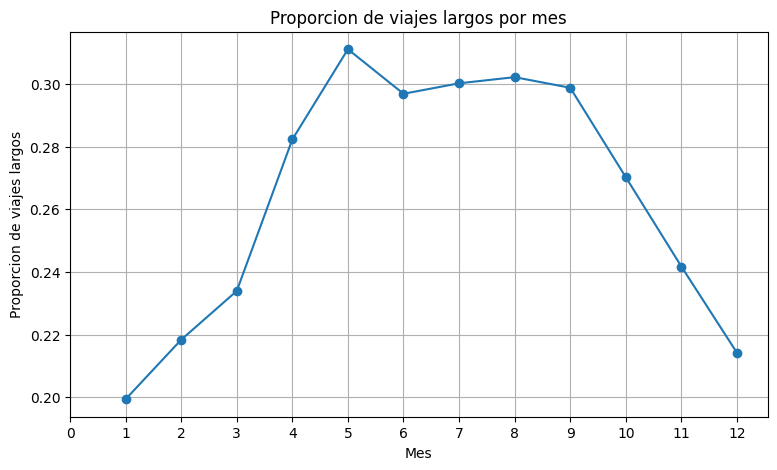

In [ ]:
hourly = df.groupby('month')['viaje_largo'].mean()

plt.figure(figsize=(9,5))
plt.plot(hourly.index, hourly.values, marker='o')
plt.title('Proporcion de viajes largos por mes')
plt.xlabel('Mes')
plt.ylabel('Proporcion de viajes largos')
plt.xticks(range(0,13))
plt.grid(True)
plt.show()

## 11. Estaciones de inicio
La estacion de inicio puede ser la mas importante, porque algunos sectores pueden generar viajes mas largos que otros.

Como hay muchas estaciones, revisamos solo estaciones con suficientes viajes para evitar conclusiones por pocos datos.

In [ ]:
estaciones = (df.groupby('start_station_id')['viaje_largo'].agg(['count', 'mean']).rename(columns={'count':'cantidad viajes', 'mean': 'promedio viajes largos'}))
estaciones_filtradas = estaciones[estaciones['cantidad viajes'] >= 100].sort_values('promedio viajes largos', ascending=False)

print(estaciones_filtradas.shape)
estaciones_filtradas.head(15)

(567, 2)


,cantidad viajes,promedio viajes largos
start_station_id,,
3331,180,0.733333
3374,346,0.693642
3320,178,0.640449
532,887,0.617813
3169,388,0.608247
3323,217,0.599078
3178,299,0.598662
427,691,0.594790
259,754,0.588859


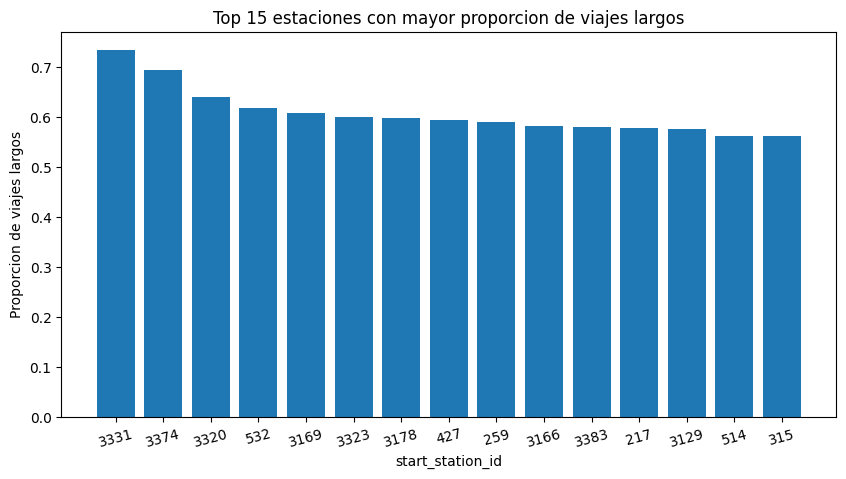

In [ ]:
top_estaciones = estaciones_filtradas.head(15)

plt.figure(figsize=(10,5))
plt.bar(top_estaciones.index.astype(str), top_estaciones['promedio viajes largos'])
plt.title('Top 15 estaciones con mayor proporcion de viajes largos')
plt.xlabel('start_station_id')
plt.ylabel('Proporcion de viajes largos')
plt.xticks(rotation=15)
plt.show()

## 12. Comparar duracion por grupos

Ademas de la variable binaria, puede ser importante revisar la duracion real para entender diferencias entre gurpos

In [ ]:
df.groupby('usertype')['tripduration'].agg(['count', 'median', 'mean'])

,count,median,mean
usertype,,,
Customer,8297,1269.0,1417.782331
Subscriber,466194,579.0,737.035239


In [ ]:
df.groupby('gender')['tripduration'].agg(['count', 'median', 'mean'])

,count,median,mean
gender,,,
female,114065,666.0,831.215219
male,354962,558.0,715.223041
unknown,5464,1039.0,1221.66563


In [ ]:
df.groupby('is_weekend')['tripduration'].agg(['count', 'median', 'mean'])

,count,median,mean
is_weekend,,,
0,371912,578.0,733.289862
1,102579,612.0,805.676084


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 474491 entries, 0 to 474490
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   tripduration      474491 non-null  Int64         
 1   starttime         474491 non-null  datetime64[us]
 2   start_station_id  474491 non-null  Int64         
 3   end_station_id    474491 non-null  Int64         
 4   usertype          474491 non-null  object        
 5   gender            474491 non-null  object        
 6   birth_year        474491 non-null  Int64         
 7   viaje_largo       474491 non-null  int64         
 8   year              474491 non-null  int32         
 9   month             474491 non-null  int32         
 10  hour              474491 non-null  int32         
 11  dayofweek         474491 non-null  int32         
 12  is_weekend        474491 non-null  int64         
 13  age               474491 non-null  Int64         
dtypes: I

# **3. CONCLUSIONES**

### **Respecto al EDA**


El EDA construido sí es util para el modelo planteado en el inicio porque no solo describe los datos, si no que permitió identificar patrones reales en el comportamiento de los viajes. Esos patrones son los que el modelo intentara aprender.

Por ejemplo, al analizar la proporcion de viajes largos segun el **tipo de usuario** se encontró una diferencia muy marcada
> *"Los usuarios que son de tipo COSTUMER tienen una probabilidad mucho mayor de realizar viajes largos en comparacion a los usuarios de tipo SUSCRIBER"*

Esto demuestra que hay variables como `usertype` que no son un dato cualquiera, sino una variable que aporta informacion relevante para anticipar el comportamiento del viaje.

Algo similar ocurre con la **hora del dia**. En los graficos se observa que hay momentos donde la proporcion de viajes largos aumenta, especialmente en la tarde y noche. Esto sugiere que el contexto temporal influye en la duracion del viaje, probablemente porque cambia el proposito del uso de la bicicleta (transporte vs recreacion). El modelo aprovecharia esta informacion para ajustar sus probabilidades dependiendo de la hora en que comienza el viaje.

El mes y la condicion de fin de semana tambien muestran variaciones claras. Hay meses donde los viajes largos son mas frecuentes, lo que puede estar relacionado con factores como el clima o turismo. Asimismo, los fines de semana presentan una mayor proporcion de viajes largos, lo que refuerza la idea de uso recreativo mencionada anteriormente. Todas estas variables, aunque por si solas no determinan completamente el resultado, en conjunto ayudan al modelo a construir una estimacion mas informada.

En ese sentido, el EDA cumplió un rol fundamental: justifica por qué esas variables fueron seleccionadas para el modelo. No son columnas al azar, si no que estamos usando evidencia para decidir que informacion tiene sentido incluir en el aprendizaje del modelo a construir.

### **Respecto al modelo**

En cuanto al modelo, lo que estamos haciendo es un **problema de clasificacion binaria**. Estamos tomando ejemplos de viajes pasados donde tenemos la duracion, y los etiquetamos como **VIAJE LARGO** o **VIAJE CORTO** segun un umbral (15 minutos en este caso). El modelo aprende a partir de estos ejemplos y luego intentara predecir cada etiqueta para los casos nuevos usando unicamente la informacion disponible al inicio del viaje.

La mejor eleccion para este contexto es **Logistic Regression**. A diferencia de modelos mas complejos, este tipo de modelo es facil de interpretar y esta diseñado para estimar probabilidades. En lugar de decir simplemente un **SÍ** o **NO** el modelo calcula una probabilidad de que el viaje sea largo. Por ejemplo, puede decir que un viaje tiene un 0.65 de probabilidad de ser largo. Ese output es mucho mas valioso porque permite tomar decisiones dependiendo del contexto, como ajustar el threshold segun lo que se quiera priorizar (detectar mas viajes largos o evitar errores)

Lo importante es entender que quiere lograr realmente el modelo. No esta tratando de adivinar con certeza absoluta si un viaje sera largo, si no que estaria estimando una probabilidad basada en el contexto del usuario y del momento en que inicia el viaje. En ese sentido, el modelo si cumple con su proposito, porque traduce patrones observados en el EDA en una herramienta cuantitativa que permite evaluar el "riesgo" o la "tendencia" de un viaje a ser largo.

> #### EDA → Identifica patrones
> #### Modelo → Intenta capturarlos

Aunque el rendimiento no es alto, es suficiente para demostrar que existe señal en los datos y que es posible construir un modelo de Machine Learning que entregue estimaciones utiles.

---
# **4. TESTEOS**

### Herramientas automatizadas para el de analisis de datos **(EDA)**

### 1. YData Profiling

In [ ]:
!pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 80.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 48.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 7.5 MB/s eta 0:00:00


In [ ]:
from ydata_profiling import ProfileReport
import pandas as pd

df = pd.read_parquet("citibike_trips.parquet")
profile = ProfileReport(df)
profile.to_file("report.html")

/tmp/ipykernel_3132/1250220210.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 7/7 [00:04<00:00,  1.59it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

### 2. DTale

Este script solo funciona ejecutandose como `.py` en tu PC localmente.

- Debes instalar la libreria con `pip install dtale`

**NOTA:**  Personalmente `YData Profiling` es mas intuitiva y agradable visualmente.

In [ ]:
# NO EJECUTAR AQUI
import dtale
import pandas as pd

df = pd.read_parquet("citibike_trips.parquet")
d = dtale.show(df, host='127.0.0.1')
print(f"Accede manualmente desde esta URL: {d.main_url()}")
input("Presiona Enter para cerrar el servidor de D-Tale...")

### 3. OpenRefine

No esta testeada por mi aun, pero entiendo que es similar a DataPrep de Google Cloud.

- Puedes descargarlo desde: https://openrefine.org/download

COMPLETAR CON LA MODA